# 🧠 Dự Đoán Người Dùng Có Bị Trầm Cảm Cao Không Dựa Trên Hành Vi Điện Thoại
## Khai Phá Dữ Liệu — Project Cuối Kỳ

---

| Thông tin | Chi tiết |
|---|---|
| **Đề tài** | Dự đoán người dùng có bị trầm cảm cao (Depression_Score > 60) dựa trên hành vi sử dụng điện thoại |
| **Dataset** | [Global Mobile Phone Addiction Dataset](https://www.kaggle.com/datasets/khushikyad001/global-mobile-phone-addiction-dataset) |
| **Loại bài toán** | Binary Classification |
| **Biến mục tiêu** | `high_depression` = 1 nếu Depression_Score > 60, ngược lại = 0 |
| **Thuật toán** | Logistic Regression · Random Forest · XGBoost |

---

### Cấu trúc notebook

| Chương | Nội dung |
|---|---|
| Chương 1 | Giới thiệu |
| Chương 2 | Mô tả dữ liệu |
| Chương 3 | Phương pháp khai phá dữ liệu |
| Chương 4 | Thực nghiệm (EDA + Tiền xử lý + Mô hình) |
| Chương 5 | Kết quả & Đánh giá |
| Chương 6 | Thảo luận & Kết luận |

## 0. Cài đặt thư viện

In [1]:
# Chạy cell này lần đầu nếu chưa cài đặt môi trường 
# !pip install notebook ipykernel pandas numpy scikit-learn matplotlib seaborn xgboost


## 1. Import thư viện & Cấu hình chung

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, f_oneway, ttest_ind
from collections import Counter

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, learning_curve)
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, export_text
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score, roc_auc_score,
                                     confusion_matrix, classification_report,
                                     roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Hằng số dùng chung
DATA_PATH     = './data/mobile_addiction_data.csv'   # ← đổi đường dẫn nếu cần
DEP_THRESHOLD = 60                             # ngưỡng trầm cảm cao
COLORS        = {'0': '#4CAF50', '1': '#F44336',
                 'pos': '#F44336', 'neg': '#2196F3'}
RANDOM_STATE  = 42

print("✅ Import hoàn tất!")

✅ Import hoàn tất!


## Chương 1 — Giới thiệu

### 1.1 Bối cảnh bài toán

Trầm cảm (depression) là một trong những rối loạn tâm thần phổ biến nhất thế giới, ảnh hưởng đến hơn 280 triệu người theo WHO (2023). Nghiên cứu hiện đại chỉ ra mối liên hệ ngày càng rõ giữa việc sử dụng điện thoại thông minh quá mức và các dấu hiệu trầm cảm — đặc biệt ở nhóm người dùng mạng xã hội nhiều giờ, ngủ ít và ít vận động thể chất.

Tuy nhiên, việc phát hiện sớm trầm cảm hiện nay vẫn phụ thuộc chủ yếu vào tự khai báo hoặc thăm khám lâm sàng — tốn kém, chậm trễ và có nhiều rào cản tiếp cận. Dữ liệu hành vi từ điện thoại thông minh là nguồn thông tin khách quan, liên tục và dễ thu thập, mở ra tiềm năng lớn cho việc phát hiện sớm các dấu hiệu trầm cảm.

### 1.2 Định nghĩa bài toán

| Thành phần | Mô tả |
|---|---|
| **Input** | Các đặc trưng hành vi sử dụng điện thoại: screen time, số lần mở khóa, thời gian mạng xã hội, game, nhắn tin, thông báo đẩy, giờ ngủ, vận động thể chất... |
| **Output** | Nhãn nhị phân: `1` = trầm cảm cao (Depression_Score > 60), `0` = bình thường |
| **Loại bài toán** | Binary Classification |
| **Thuật toán** | Logistic Regression, Random Forest, XGBoost |

### 1.3 Các giải pháp hiện tại

- **Bảng câu hỏi lâm sàng** (PHQ-9, BDI): chuẩn hóa nhưng cần chuyên gia và tốn thời gian
- **Ứng dụng sức khỏe tâm thần** (Woebot, Wysa): hỗ trợ nhưng không phát hiện chủ động
- **Phân tích hành vi kỹ thuật số**: hướng nghiên cứu mới, tiềm năng cao nhưng chưa phổ biến

### 1.4 Vai trò của khai phá dữ liệu

Khai phá dữ liệu cho phép xây dựng mô hình tự động học mối quan hệ giữa các hành vi sử dụng điện thoại và mức độ trầm cảm từ dữ liệu lịch sử — không cần can thiệp thủ công và có thể triển khai ở quy mô lớn.

### 1.5 Ứng dụng dự kiến

- Tích hợp vào ứng dụng di động để cảnh báo sớm nguy cơ trầm cảm
- Hỗ trợ hệ thống y tế số sàng lọc bệnh nhân cần tư vấn tâm lý
- Nghiên cứu dịch tễ học về tác động của điện thoại đến sức khỏe tâm thần

## Chương 2 — Mô tả dữ liệu

### 2.1 Tải dữ liệu & Thông tin tổng quan

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"📊 Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print()
print("5 dòng đầu tiên:")
df.head()

📊 Kích thước: 3,000 dòng × 34 cột

5 dòng đầu tiên:


,User_ID,Country,Age,Gender,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,...,Online_Shopping_Hours,Internet_Connection_Type,Primary_Device_Brand,Has_Screen_Time_Management_App,Self_Reported_Addiction_Level,Monthly_Data_Usage_GB,Has_Night_Mode_On,Age_First_Phone,Push_Notifications_Per_Day,Tech_Savviness_Score
0,1,India,32,Male,Salesperson,High School,43865.49,5.81,75,0.84,...,1.85,5G,Other,No,Low,16.43,Yes,16,106,39.36
1,2,UK,26,Male,Artist,Master's,41868.19,9.05,61,3.13,...,0.66,4G,Samsung,Yes,Severe,32.87,No,12,111,9.45
2,3,Germany,70,Other,Doctor,High School,59636.51,5.76,58,2.12,...,-0.14,WiFi,Samsung,Yes,Severe,27.45,No,18,90,50.27
3,4,UK,44,Female,Engineer,NaN,39022.07,6.71,80,1.60,...,0.17,3G,Apple,Yes,Moderate,30.85,No,17,60,30.82
4,5,Brazil,46,Other,Student,NaN,-783.98,6.31,136,1.51,...,0.58,3G,Xiaomi,No,High,10.38,Yes,18,127,21.70


### 2.2 Kiểu dữ liệu & Cấu trúc cột

In [4]:
print("=== KIỂU DỮ LIỆU ===")
type_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null': df.notnull().sum().values,
    'Unique': df.nunique().values
})
print(type_df.to_string(index=False))

=== KIỂU DỮ LIỆU ===
                        Column   Dtype  Non-Null  Unique
                       User_ID   int64      3000    3000
                       Country  object      3000      10
                           Age   int64      3000      59
                        Gender  object      3000       3
                    Occupation  object      3000       8
               Education_Level  object      2388       4
                    Income_USD float64      3000    2999
       Daily_Screen_Time_Hours float64      3000     839
         Phone_Unlocks_Per_Day   int64      3000     150
      Social_Media_Usage_Hours float64      3000     480
            Gaming_Usage_Hours float64      3000     482
         Streaming_Usage_Hours float64      3000     479
         Messaging_Usage_Hours float64      3000     268
      Work_Related_Usage_Hours float64      3000     477
                   Sleep_Hours float64      3000     489
       Physical_Activity_Hours float64      3000     275
          

### 2.3 Missing values & Giá trị âm bất thường

In [5]:
# Missing values
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print("✅ Không có missing values!" if missing.sum() == 0
      else missing[missing > 0].to_string())

# Giá trị âm bất thường
neg_cols = [
    'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day', 'Social_Media_Usage_Hours',
    'Gaming_Usage_Hours', 'Streaming_Usage_Hours', 'Messaging_Usage_Hours',
    'Work_Related_Usage_Hours', 'Physical_Activity_Hours', 'Monthly_Data_Usage_GB',
    'Push_Notifications_Per_Day', 'Income_USD', 'Time_Spent_With_Family_Hours',
    'Online_Shopping_Hours'
]
print("=== GIÁ TRỊ ÂM BẤT THƯỜNG ===")
total_neg = 0
for c in neg_cols:
    n = (df[c] < 0).sum()
    if n > 0:
        print(f"  ⚠️  {c:<42} {n} giá trị")
        total_neg += n
print(f"  Tổng: {total_neg} giá trị âm cần xử lý")

=== MISSING VALUES ===
Education_Level    612
=== GIÁ TRỊ ÂM BẤT THƯỜNG ===
  ⚠️  Daily_Screen_Time_Hours                    9 giá trị
  ⚠️  Phone_Unlocks_Per_Day                      1 giá trị
  ⚠️  Social_Media_Usage_Hours                   70 giá trị
  ⚠️  Gaming_Usage_Hours                         213 giá trị
  ⚠️  Streaming_Usage_Hours                      67 giá trị
  ⚠️  Messaging_Usage_Hours                      2 giá trị
  ⚠️  Work_Related_Usage_Hours                   53 giá trị
  ⚠️  Physical_Activity_Hours                    80 giá trị
  ⚠️  Monthly_Data_Usage_GB                      16 giá trị
  ⚠️  Push_Notifications_Per_Day                 3 giá trị
  ⚠️  Income_USD                                 81 giá trị
  ⚠️  Time_Spent_With_Family_Hours               96 giá trị
  ⚠️  Online_Shopping_Hours                      181 giá trị
  Tổng: 872 giá trị âm cần xử lý


### 2.4 Thống kê mô tả

In [6]:
num_cols = [
    'Age', 'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day',
    'Social_Media_Usage_Hours', 'Gaming_Usage_Hours', 'Streaming_Usage_Hours',
    'Messaging_Usage_Hours', 'Work_Related_Usage_Hours', 'Sleep_Hours',
    'Physical_Activity_Hours', 'Mental_Health_Score', 'Depression_Score',
    'Anxiety_Score', 'Stress_Level', 'Monthly_Data_Usage_GB', 'Age_First_Phone',
    'Push_Notifications_Per_Day', 'Tech_Savviness_Score', 'Income_USD',
    'Time_Spent_With_Family_Hours', 'Online_Shopping_Hours'
]
df[num_cols].describe().round(2)

,Age,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,Gaming_Usage_Hours,Streaming_Usage_Hours,Messaging_Usage_Hours,Work_Related_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,...,Depression_Score,Anxiety_Score,Stress_Level,Monthly_Data_Usage_GB,Age_First_Phone,Push_Notifications_Per_Day,Tech_Savviness_Score,Income_USD,Time_Spent_With_Family_Hours,Online_Shopping_Hours
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,...,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,41.31,5.98,79.70,1.99,1.49,1.98,1.49,2.00,6.49,1.00,...,50.34,49.92,49.38,24.87,13.95,99.05,49.46,29779.51,1.45,0.79
std,17.05,2.02,25.16,0.98,1.00,1.00,0.51,0.97,0.99,0.50,...,29.00,29.04,28.59,9.79,3.74,30.33,28.84,15377.47,0.80,0.51
min,12.00,-0.50,-7.00,-1.81,-1.93,-1.91,-0.18,-1.16,2.81,-0.84,...,0.04,0.01,0.04,-10.96,8.00,-21.00,0.01,-25622.66,-1.61,-0.88
25%,27.00,4.60,63.00,1.34,0.81,1.29,1.14,1.34,5.84,0.65,...,25.66,24.67,24.26,18.30,11.00,79.00,23.66,19482.70,0.92,0.46
50%,42.00,5.98,80.00,2.01,1.51,2.01,1.50,1.98,6.48,1.01,...,50.16,50.12,48.80,25.04,14.00,99.00,49.15,30002.71,1.45,0.78
75%,56.00,7.30,96.00,2.64,2.18,2.65,1.84,2.67,7.16,1.33,...,75.42,75.40,74.42,31.46,17.00,119.00,74.14,40352.02,1.99,1.13
max,70.00,12.87,182.00,5.05,4.86,5.18,3.07,5.26,10.32,2.80,...,99.83,100.00,99.88,54.85,20.00,204.00,99.94,79829.55,4.52,2.60


### 2.5 Phân bố biến phân loại

In [7]:
cat_cols = [
    'Gender', 'Occupation', 'Education_Level', 'Country',
    'Relationship_Status', 'Urban_or_Rural', 'Internet_Connection_Type',
    'Primary_Device_Brand', 'Has_Screen_Time_Management_App',
    'Self_Reported_Addiction_Level', 'Has_Night_Mode_On'
]
for c in cat_cols:
    counts = df[c].value_counts()
    print(f"{'─'*50}")
    print(f"  {c}")
    print(f"{'─'*50}")
    for val, cnt in counts.items():
        bar = '█' * int(cnt / len(df) * 50)
        print(f"  {str(val):<28} {cnt:>5}  ({cnt/len(df)*100:5.1f}%)  {bar}")

──────────────────────────────────────────────────
  Gender
──────────────────────────────────────────────────
  Male                          1047  ( 34.9%)  █████████████████
  Other                          990  ( 33.0%)  ████████████████
  Female                         963  ( 32.1%)  ████████████████
──────────────────────────────────────────────────
  Occupation
──────────────────────────────────────────────────
  Unemployed                     392  ( 13.1%)  ██████
  Doctor                         387  ( 12.9%)  ██████
  Artist                         386  ( 12.9%)  ██████
  Salesperson                    383  ( 12.8%)  ██████
  Teacher                        383  ( 12.8%)  ██████
  Engineer                       364  ( 12.1%)  ██████
  Student                        355  ( 11.8%)  █████
  Manager                        350  ( 11.7%)  █████
──────────────────────────────────────────────────
  Education_Level
──────────────────────────────────────────────────
  High School       

### 2.6 Giả thiết khi thu thập dữ liệu

> **Lưu ý quan trọng về chất lượng dữ liệu:**
>
> Sau khi phân tích, dataset này là **synthetic data** (dữ liệu tổng hợp). Các cột được sinh ngẫu nhiên độc lập với nhau — kể cả các cột sức khỏe tâm thần cũng không có tương quan với nhau (Depression vs Anxiety: r ≈ -0.009, Depression vs Stress: r ≈ -0.004). Đây là vấn đề gốc rễ ảnh hưởng đến kết quả mô hình, sẽ được phân tích kỹ trong Chương 5.
>
> **Các giả thiết khi thu thập:**
> - Nhãn `Depression_Score` là điểm tự đánh giá của người dùng, không qua thẩm định lâm sàng
> - Dữ liệu hành vi được ghi nhận liên tục và chính xác
> - Phân bố địa lý đa dạng (10 quốc gia) nhưng không đại diện cho thực tế

## Chương 3 — Phương pháp khai phá dữ liệu

### 3.1 Quy trình tổng thể

```
Dữ liệu thô (CSV)
      ↓
[Bước 1] Tiền xử lý: clip giá trị âm, tạo nhãn nhị phân, mã hóa categorical
      ↓
[Bước 2] EDA: thống kê, tương quan, trực quan hóa
      ↓
[Bước 3] Chia Train/Test (80/20, stratified)
      ↓
[Bước 4] Chuẩn hóa StandardScaler
      ↓
[Bước 5] Huấn luyện 3 mô hình: Logistic Regression · Random Forest · XGBoost
      ↓
[Bước 6] Đánh giá: Accuracy, Precision, Recall, F1, AUC, Cross-Validation
      ↓
[Bước 7] So sánh & Phân tích kết quả
```

### 3.2 Nguyên lý các thuật toán

#### 3.2.1 Logistic Regression
Mô hình tuyến tính dự đoán xác suất nhị phân thông qua hàm sigmoid:
$$P(y=1|X) = \\frac{1}{1 + e^{-(w^T X + b)}}$$
Phù hợp làm baseline vì đơn giản, dễ giải thích, không cần nhiều dữ liệu.

#### 3.2.2 Random Forest
Ensemble của nhiều Decision Tree, mỗi cây huấn luyện trên bootstrap sample. Kết quả là majority vote. Giảm variance so với single tree, ít overfitting.

#### 3.2.3 XGBoost
Gradient Boosting tối ưu hóa cao: các cây được xây dựng tuần tự, mỗi cây sửa lỗi cây trước bằng gradient descent. Có regularization L1/L2 tránh overfitting.

### 3.3 Tham số mô hình

| Mô hình | Tham số chính | Lý do |
|---|---|---|
| Logistic Regression | `max_iter=1000`, `C=1.0` | Đủ vòng lặp hội tụ, regularization mặc định |
| Random Forest | `n_estimators=100`, `random_state=42` | 100 cây cho độ ổn định, tái lập được |
| XGBoost | `n_estimators=100`, `eval_metric='logloss'` | logloss phù hợp binary classification |

### 3.4 Tiêu chí đánh giá

| Tiêu chí | Công thức | Ý nghĩa |
|---|---|---|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Tỷ lệ dự đoán đúng tổng thể |
| **Precision** | TP/(TP+FP) | Trong số dự đoán trầm cảm, bao nhiêu đúng |
| **Recall** | TP/(TP+FN) | Trong số thực sự trầm cảm, phát hiện được bao nhiêu |
| **F1-score** | 2×(P×R)/(P+R) | Cân bằng Precision và Recall |
| **AUC-ROC** | Diện tích dưới ROC curve | Khả năng phân biệt 2 lớp (0.5 = random) |
| **CV-5fold** | Mean accuracy qua 5 folds | Độ ổn định của mô hình |

## Chương 4 — Thực nghiệm

### 4.1 Yêu cầu môi trường

| Thành phần | Phiên bản |
|---|---|
| Python | 3.10+ |
| pandas | 2.x |
| numpy | 1.24+ |
| scikit-learn | 1.3+ |
| xgboost | 1.7+ |
| matplotlib / seaborn | 3.7+ / 0.12+ |
| Máy tính | RAM 8GB+, CPU 4 cores+ |

### 4.2 Bước 1 — Tiền xử lý dữ liệu

In [8]:
# ── Tạo bản sao để xử lý ──────────────────────────────────────────────────────
df_clean = df.copy()

# ── Clip giá trị âm về 0 ──────────────────────────────────────────────────────
neg_cols = [
    'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day', 'Social_Media_Usage_Hours',
    'Gaming_Usage_Hours', 'Streaming_Usage_Hours', 'Messaging_Usage_Hours',
    'Work_Related_Usage_Hours', 'Physical_Activity_Hours', 'Monthly_Data_Usage_GB',
    'Push_Notifications_Per_Day', 'Income_USD', 'Time_Spent_With_Family_Hours',
    'Online_Shopping_Hours'
]
n_neg_before = sum((df_clean[c] < 0).sum() for c in neg_cols)
for c in neg_cols:
    df_clean[c] = df_clean[c].clip(lower=0)
print(f"✅ Đã clip {n_neg_before} giá trị âm về 0")

# ── Tạo biến mục tiêu nhị phân ────────────────────────────────────────────────
df_clean['high_depression'] = (df_clean['Depression_Score'] > DEP_THRESHOLD).astype(int)
dist = df_clean['high_depression'].value_counts()
print(f"✅ Tạo biến target 'high_depression' (ngưỡng Depression_Score > {DEP_THRESHOLD})")
print(f"   Lớp 0 (bình thường):    {dist[0]:,} ({dist[0]/len(df_clean)*100:.1f}%)")
print(f"   Lớp 1 (trầm cảm cao):  {dist[1]:,} ({dist[1]/len(df_clean)*100:.1f}%)")

# ── Encode categorical features ───────────────────────────────────────────────
cat_feats = ['Gender', 'Occupation', 'Education_Level', 'Relationship_Status',
             'Has_Children', 'Urban_or_Rural', 'Internet_Connection_Type',
             'Primary_Device_Brand', 'Has_Screen_Time_Management_App', 'Has_Night_Mode_On']
le_dict = {}
for c in cat_feats:
    le = LabelEncoder()
    df_clean[c + '_enc'] = le.fit_transform(df_clean[c].astype(str))
    le_dict[c] = le
print(f"✅ Đã mã hóa {len(cat_feats)} biến categorical")

# ── Chọn feature set ──────────────────────────────────────────────────────────
behavior_feats = [
    'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day', 'Social_Media_Usage_Hours',
    'Gaming_Usage_Hours', 'Streaming_Usage_Hours', 'Messaging_Usage_Hours',
    'Work_Related_Usage_Hours', 'Push_Notifications_Per_Day', 'Monthly_Data_Usage_GB',
    'Online_Shopping_Hours', 'Sleep_Hours', 'Physical_Activity_Hours',
    'Age', 'Age_First_Phone', 'Tech_Savviness_Score', 'Income_USD',
    'Time_Spent_With_Family_Hours'
]
cat_enc_feats = [c + '_enc' for c in cat_feats]
ALL_FEATURES  = behavior_feats + cat_enc_feats

print(f"✅ Feature set: {len(behavior_feats)} hành vi + {len(cat_enc_feats)} categorical = {len(ALL_FEATURES)} features")

✅ Đã clip 872 giá trị âm về 0
✅ Tạo biến target 'high_depression' (ngưỡng Depression_Score > 60)
   Lớp 0 (bình thường):    1,787 (59.6%)
   Lớp 1 (trầm cảm cao):  1,213 (40.4%)
✅ Đã mã hóa 10 biến categorical
✅ Feature set: 17 hành vi + 10 categorical = 27 features


### 4.3 Bước 2 — Phân tích dữ liệu khám phá (EDA)

#### 4.3.1 Phân bố biến mục tiêu

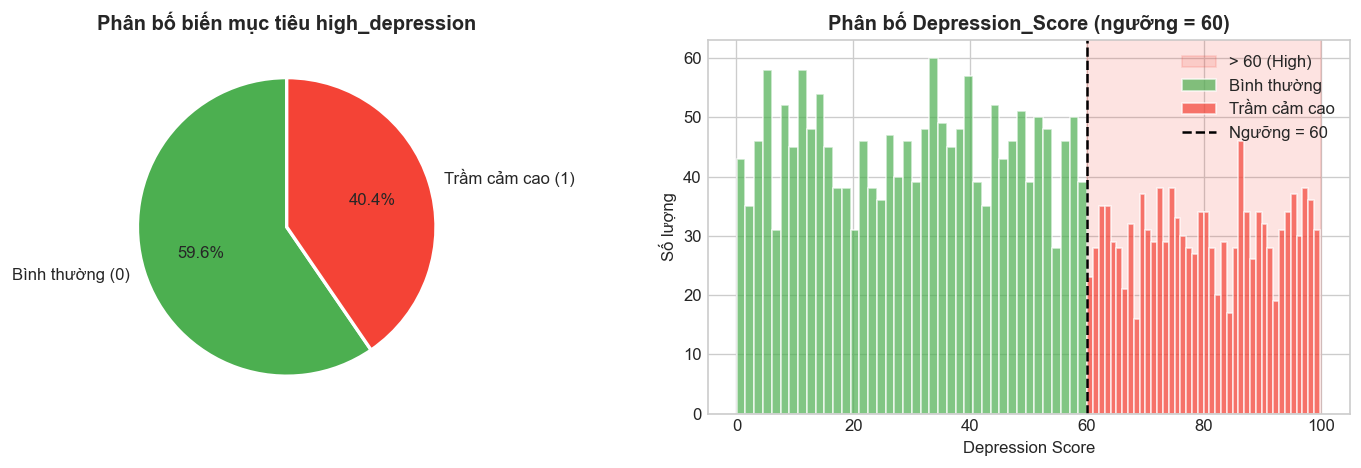

Thống kê Depression_Score:
                  count   mean    std    min    25%    50%    75%    max
high_depression                                                         
0                1787.0  29.99  17.24   0.04  14.36  30.64  44.74  60.00
1                1213.0  80.33  11.53  60.06  70.62  80.07  90.16  99.83


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
ax = axes[0]
vals = df_clean['high_depression'].value_counts()
ax.pie(vals, labels=['Bình thường (0)', 'Trầm cảm cao (1)'],
       colors=[COLORS['0'], COLORS['1']], autopct='%1.1f%%',
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Phân bố biến mục tiêu high_depression', fontweight='bold')

# Histogram Depression_Score
ax = axes[1]
ax.axvspan(DEP_THRESHOLD, 100, alpha=0.15, color=COLORS['pos'], label=f'> {DEP_THRESHOLD} (High)')
ax.hist(df_clean[df_clean['high_depression']==0]['Depression_Score'],
        bins=40, alpha=0.7, color=COLORS['0'], label='Bình thường', edgecolor='white')
ax.hist(df_clean[df_clean['high_depression']==1]['Depression_Score'],
        bins=40, alpha=0.7, color=COLORS['1'], label='Trầm cảm cao', edgecolor='white')
ax.axvline(x=DEP_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Ngưỡng = {DEP_THRESHOLD}')
ax.set_title(f'Phân bố Depression_Score (ngưỡng = {DEP_THRESHOLD})', fontweight='bold')
ax.set_xlabel('Depression Score'); ax.set_ylabel('Số lượng'); ax.legend()

plt.tight_layout()
plt.savefig('charts/01_target_distribution.png', bbox_inches='tight')
plt.show()

print(f"Thống kê Depression_Score:")
print(df_clean.groupby('high_depression')['Depression_Score'].describe().round(2))

#### 4.3.2 Tương quan features với target

In [10]:
print("=== TƯƠNG QUAN PEARSON với high_depression ===")
print(f"{'Feature':<42} {'r':>8} {'p-value':>10} {'Ý nghĩa':>12}")
print("─" * 76)

corr_results = []
for f in ALL_FEATURES:
    r, p = pearsonr(df_clean[f], df_clean['high_depression'])
    corr_results.append((f, r, p))

corr_results.sort(key=lambda x: -abs(x[1]))
for f, r, p in corr_results:
    sig = "✅ p<0.05" if p < 0.05 else "❌ p≥0.05"
    print(f"  {f:<42} {r:>+8.4f} {p:>10.4f} {sig:>12}")

# Nhận xét
sig_count = sum(1 for _,_,p in corr_results if p < 0.05)
max_r = max(abs(r) for _,r,_ in corr_results)
print(f"📌 Nhận xét:")
print(f"   - Số features có p < 0.05: {sig_count}/{len(ALL_FEATURES)}")
print(f"   - Tương quan cao nhất: r = {max_r:.4f}")
print(f"   - Kết luận: Tương quan cực kỳ thấp → dữ liệu synthetic")

=== TƯƠNG QUAN PEARSON với high_depression ===
Feature                                           r    p-value      Ý nghĩa
────────────────────────────────────────────────────────────────────────────
  Sleep_Hours                                 +0.0468     0.0103     ✅ p<0.05
  Phone_Unlocks_Per_Day                       +0.0319     0.0808     ❌ p≥0.05
  Daily_Screen_Time_Hours                     -0.0309     0.0903     ❌ p≥0.05
  Income_USD                                  +0.0294     0.1077     ❌ p≥0.05
  Monthly_Data_Usage_GB                       -0.0268     0.1422     ❌ p≥0.05
  Work_Related_Usage_Hours                    +0.0247     0.1768     ❌ p≥0.05
  Physical_Activity_Hours                     +0.0222     0.2246     ❌ p≥0.05
  Gaming_Usage_Hours                          +0.0202     0.2683     ❌ p≥0.05
  Push_Notifications_Per_Day                  +0.0202     0.2694     ❌ p≥0.05
  Messaging_Usage_Hours                       -0.0199     0.2752     ❌ p≥0.05
  Relationship_Statu

#### 4.3.3 So sánh phân bố features giữa 2 nhóm

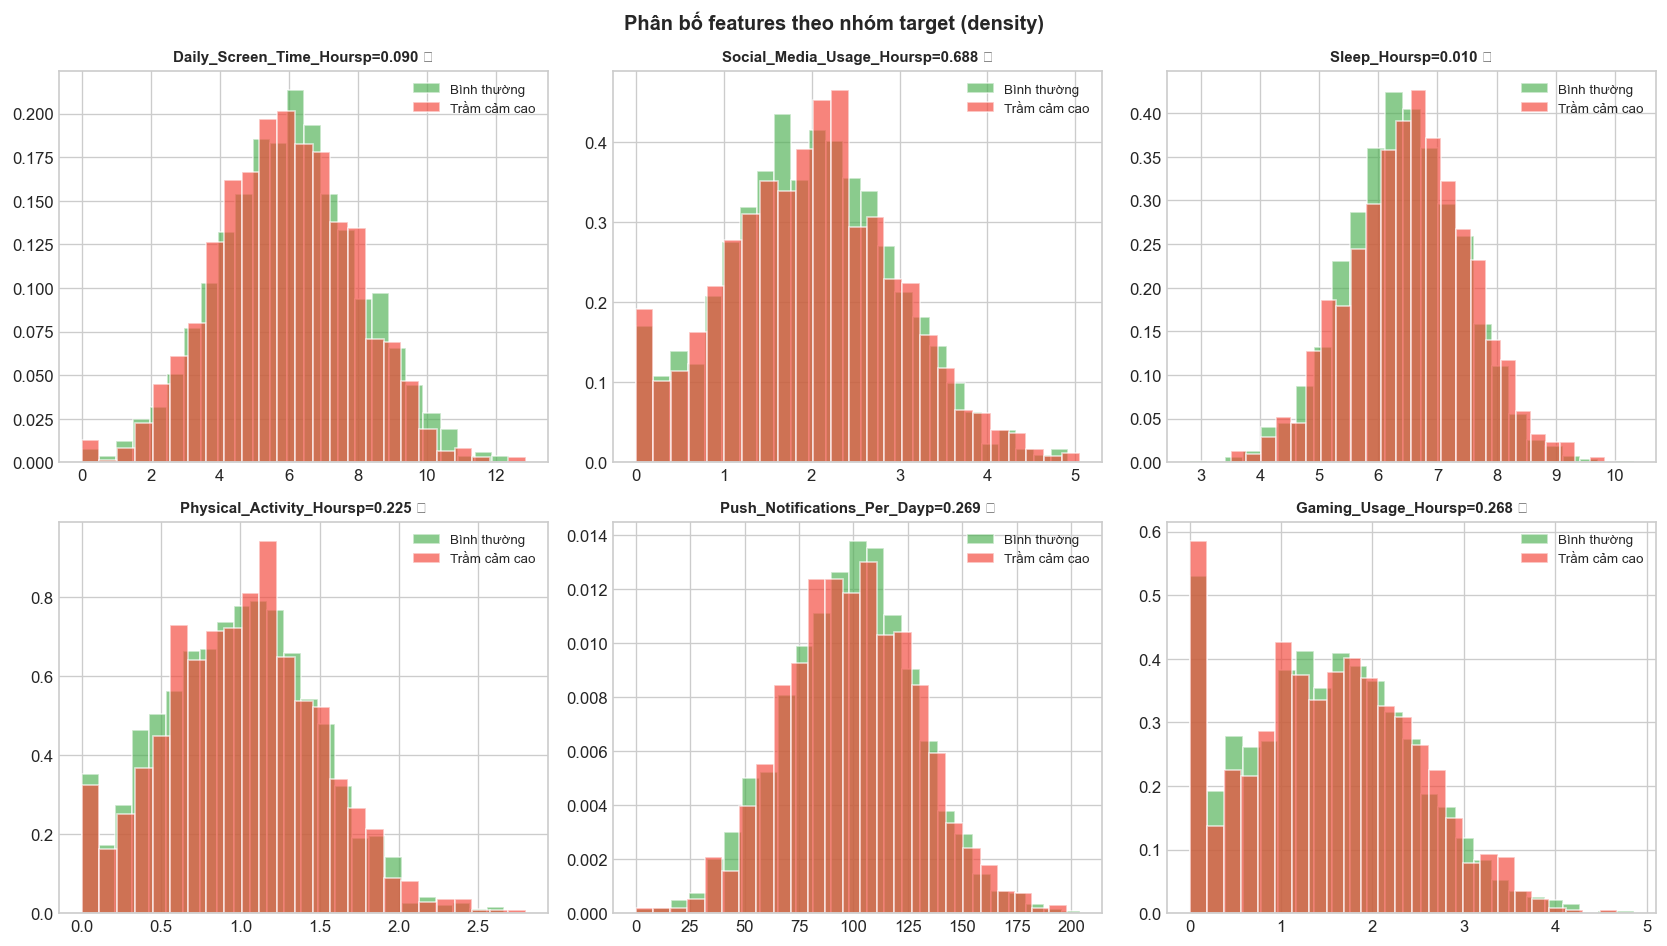

So sánh mean giữa 2 nhóm:
Feature                                     Bình thường   Trầm cảm cao     Diff
────────────────────────────────────────────────────────────────────────────────
  Daily_Screen_Time_Hours                           6.036          5.909    0.127
  Social_Media_Usage_Hours                          1.991          2.005    0.014
  Sleep_Hours                                       6.454          6.549    0.095
  Physical_Activity_Hours                           0.993          1.015    0.022
  Push_Notifications_Per_Day                       98.564         99.808    1.244
  Gaming_Usage_Hours                                1.503          1.541    0.039


In [11]:
key_feats = ['Daily_Screen_Time_Hours', 'Social_Media_Usage_Hours',
             'Sleep_Hours', 'Physical_Activity_Hours',
             'Push_Notifications_Per_Day', 'Gaming_Usage_Hours']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), key_feats):
    data0 = df_clean[df_clean['high_depression']==0][feat]
    data1 = df_clean[df_clean['high_depression']==1][feat]
    ax.hist(data0, bins=25, alpha=0.65, color=COLORS['0'],
            label='Bình thường', edgecolor='white', density=True)
    ax.hist(data1, bins=25, alpha=0.65, color=COLORS['1'],
            label='Trầm cảm cao', edgecolor='white', density=True)

    # T-test
    from scipy.stats import ttest_ind
    t, p = ttest_ind(data0, data1)
    ax.set_title(f'{feat}p={p:.3f} {"✅" if p<0.05 else "❌"}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Phân bố features theo nhóm target (density)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_feature_distributions.png', bbox_inches='tight')
plt.show()

print("So sánh mean giữa 2 nhóm:")
print(f"{'Feature':<40} {'Bình thường':>14} {'Trầm cảm cao':>14} {'Diff':>8}")
print("─" * 80)
for f in key_feats:
    m0 = df_clean[df_clean['high_depression']==0][f].mean()
    m1 = df_clean[df_clean['high_depression']==1][f].mean()
    print(f"  {f:<40} {m0:>14.3f} {m1:>14.3f} {abs(m1-m0):>8.3f}")

#### 4.3.4 Heatmap tương quan toàn bộ features

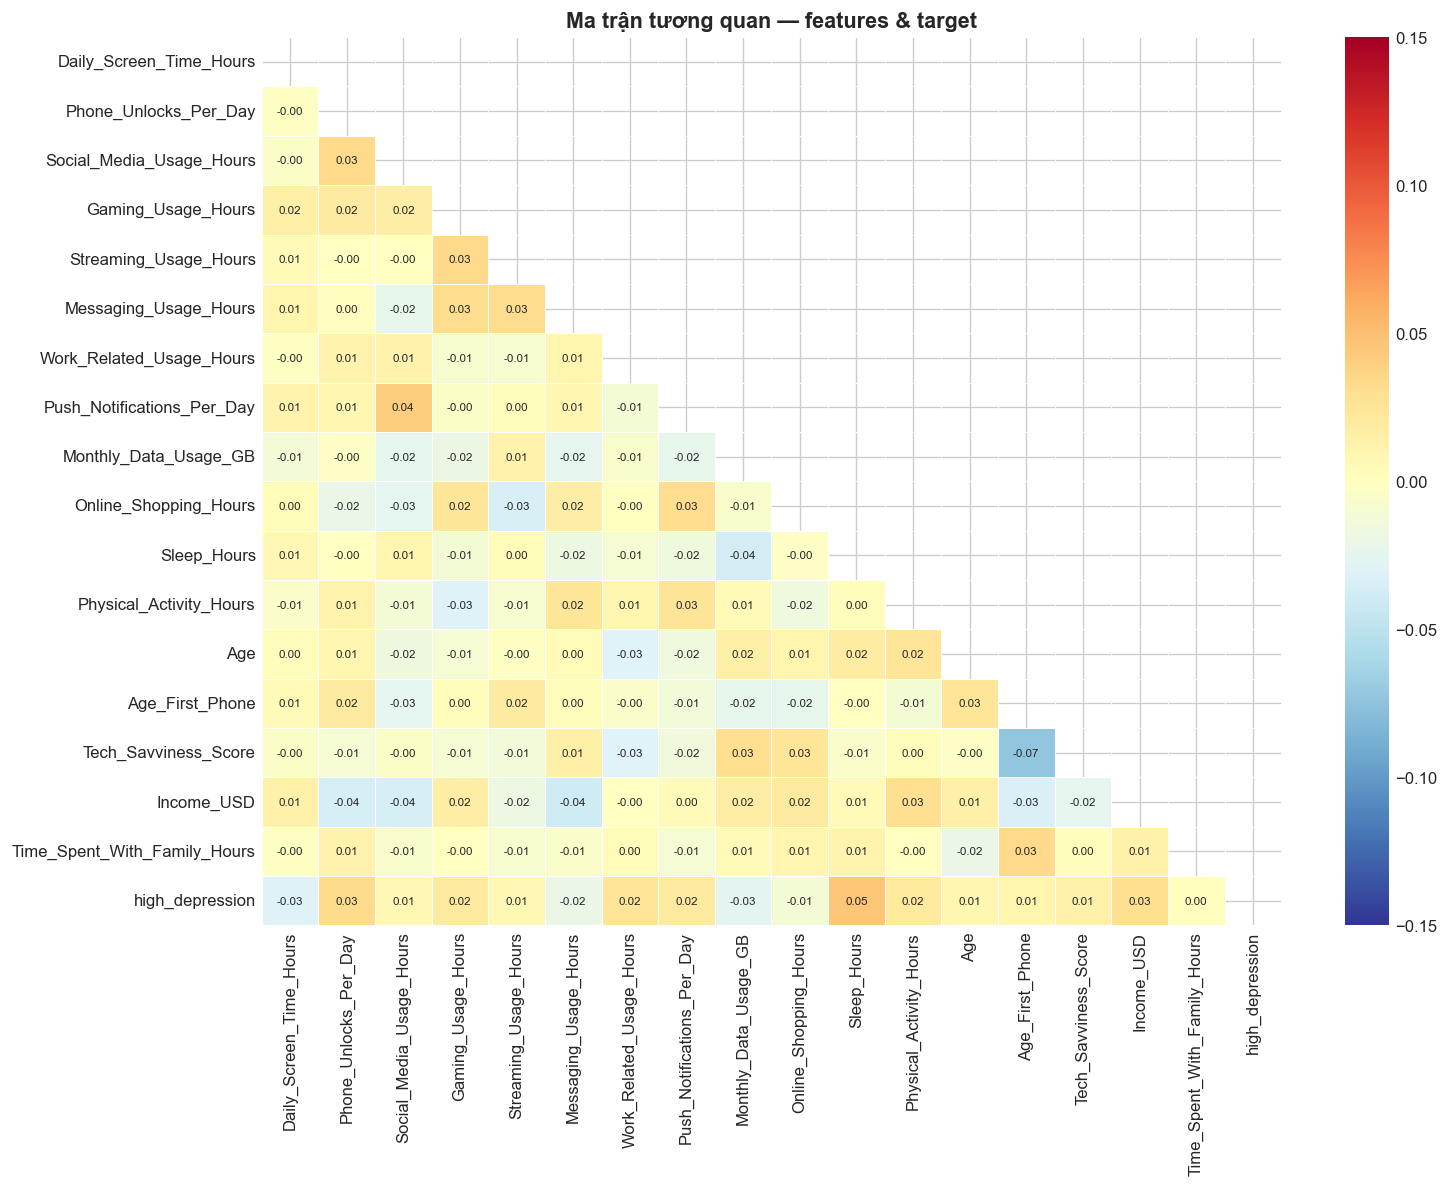

In [12]:
fig, ax = plt.subplots(figsize=(13, 10))
corr_mat = df_clean[behavior_feats + ['high_depression']].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', ax=ax, annot_kws={'size': 7},
            linewidths=0.4, vmin=-0.15, vmax=0.15)
ax.set_title('Ma trận tương quan — features & target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

#### 4.3.5 Boxplot features theo nhóm

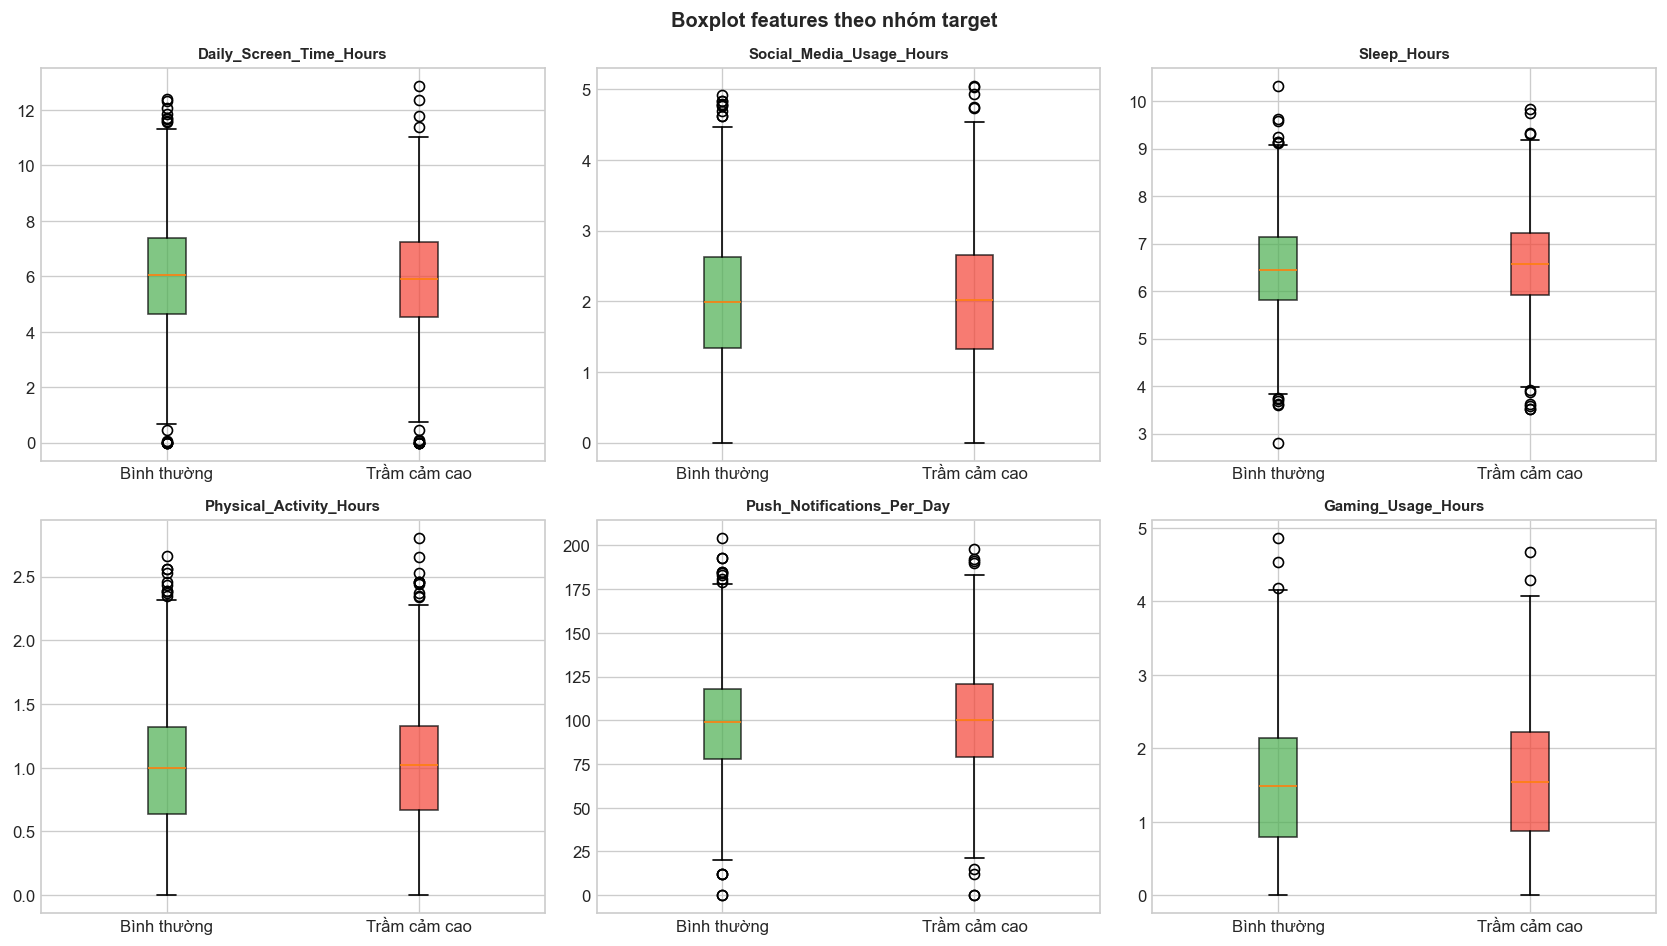

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), key_feats):
    data = [df_clean[df_clean['high_depression']==0][feat].values,
            df_clean[df_clean['high_depression']==1][feat].values]
    bp = ax.boxplot(data, labels=['Bình thường', 'Trầm cảm cao'],
                    patch_artist=True, notch=False)
    bp['boxes'][0].set_facecolor(COLORS['0']); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(COLORS['1']); bp['boxes'][1].set_alpha(0.7)
    ax.set_title(feat, fontsize=9, fontweight='bold')

fig.suptitle('Boxplot features theo nhóm target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/04_boxplots.png', bbox_inches='tight')
plt.show()

### 4.4 Bước 3 — Chuẩn hóa & Chia tập dữ liệu

In [14]:
X = df_clean[ALL_FEATURES]
y = df_clean['high_depression']

# Chuẩn hóa
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"✅ Chuẩn hóa: StandardScaler (Z-score)")
print(f"✅ Train: {X_train.shape[0]:,} mẫu  |  Test: {X_test.shape[0]:,} mẫu  (80/20, stratified)")
print(f"   Train phân bố: {dict(Counter(y_train))}")
print(f"   Test  phân bố: {dict(Counter(y_test))}")
print(f"   Majority class baseline: {max(y.mean(), 1-y.mean()):.4f}")

✅ Chuẩn hóa: StandardScaler (Z-score)
✅ Train: 2,400 mẫu  |  Test: 600 mẫu  (80/20, stratified)
   Train phân bố: {1: 970, 0: 1430}
   Test  phân bố: {0: 357, 1: 243}
   Majority class baseline: 0.5957


### 4.5 Bước 4 — Huấn luyện mô hình

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                         eval_metric='logloss', verbosity=0),
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    print(f"⏳ Đang huấn luyện: {name} ...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model':      model,
        'y_pred':     y_pred,
        'y_prob':     y_prob,
        'Accuracy':   accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred, zero_division=0),
        'Recall':     recall_score(y_test, y_pred, zero_division=0),
        'F1-score':   f1_score(y_test, y_pred, zero_division=0),
        'AUC':        roc_auc_score(y_test, y_prob),
        'CV_Acc':     cross_val_score(model, X_scaled, y,
                                       cv=cv_strategy, scoring='accuracy').mean(),
    }
    r = results[name]
    print(f"   ✅ Acc={r['Accuracy']:.4f}  F1={r['F1-score']:.4f}  AUC={r['AUC']:.4f}  CV={r['CV_Acc']:.4f}")

print("🎉 Hoàn tất huấn luyện!")

⏳ Đang huấn luyện: Logistic Regression ...
   ✅ Acc=0.5767  F1=0.0797  AUC=0.4869  CV=0.5910
⏳ Đang huấn luyện: Random Forest ...
   ✅ Acc=0.5733  F1=0.1742  AUC=0.4944  CV=0.5803
⏳ Đang huấn luyện: XGBoost ...
   ✅ Acc=0.5367  F1=0.3653  AUC=0.5063  CV=0.5537
🎉 Hoàn tất huấn luyện!


## Chương 5 — Kết quả

### 5.1 Bảng tổng hợp hiệu suất

In [16]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC', 'CV_Acc']
df_res  = pd.DataFrame({n: {m: round(results[n][m], 4) for m in metrics}
                        for n in results}).T

# Thêm baseline
majority_class = max(y.mean(), 1-y.mean())
df_res.loc['Majority Baseline'] = [round(majority_class,4), 0, 0, 0, 0.5, round(majority_class,4)]
df_res.index.name = 'Mô hình'

def highlight(s):
    vals = s[:-1].astype(float)
    return ['background-color:#bbdefb;color:black; font-weight:bold'
            if (i < len(s)-1 and s.iloc[i] == vals.max()) else ''
            for i in range(len(s))]

print("Majority class baseline:", round(majority_class, 4),
      f"({(1-y.mean())*100:.1f}% lớp 0 — lớp chiếm đa số)")
df_res.style.apply(highlight).format("{:.4f}")

Majority class baseline: 0.5957 (59.6% lớp 0 — lớp chiếm đa số)


,Accuracy,Precision,Recall,F1-score,AUC,CV_Acc
Mô hình,,,,,,
Logistic Regression,0.5767,0.3333,0.0453,0.0797,0.4869,0.5910
Random Forest,0.5733,0.4030,0.1111,0.1742,0.4944,0.5803
XGBoost,0.5367,0.4103,0.3292,0.3653,0.5063,0.5537
Majority Baseline,0.5957,0.0000,0.0000,0.0000,0.5000,0.5957


### 5.2 Classification Report chi tiết

In [17]:
for name, r in results.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, r['y_pred'],
                                 target_names=['Bình thường (0)', 'Trầm cảm cao (1)']))

  Logistic Regression
                  precision    recall  f1-score   support

 Bình thường (0)       0.59      0.94      0.73       357
Trầm cảm cao (1)       0.33      0.05      0.08       243

        accuracy                           0.58       600
       macro avg       0.46      0.49      0.40       600
    weighted avg       0.49      0.58      0.46       600

  Random Forest
                  precision    recall  f1-score   support

 Bình thường (0)       0.59      0.89      0.71       357
Trầm cảm cao (1)       0.40      0.11      0.17       243

        accuracy                           0.57       600
       macro avg       0.50      0.50      0.44       600
    weighted avg       0.52      0.57      0.49       600

  XGBoost
                  precision    recall  f1-score   support

 Bình thường (0)       0.60      0.68      0.64       357
Trầm cảm cao (1)       0.41      0.33      0.37       243

        accuracy                           0.54       600
       macro avg

### 5.3 Biểu đồ so sánh hiệu suất các mô hình

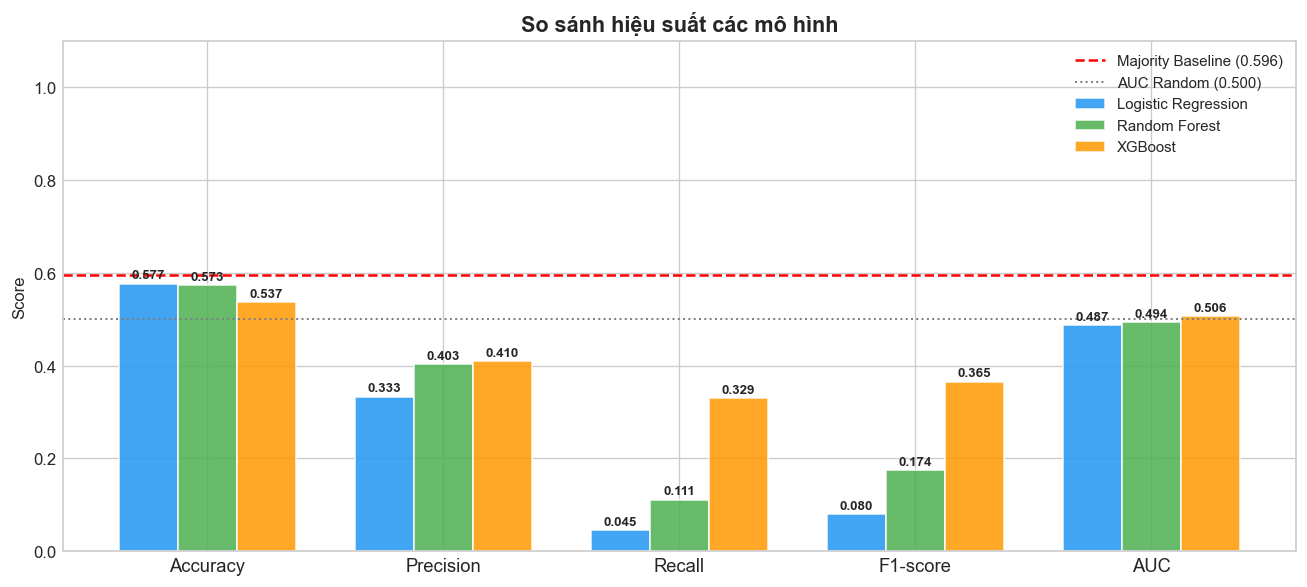

In [18]:
bar_colors  = ['#2196F3', '#4CAF50', '#FF9800']
show_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']
x     = np.arange(len(show_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, color) in enumerate(zip(results.keys(), bar_colors)):
    vals  = [results[name][m] for m in show_metrics]
    rects = ax.bar(x + i*width, vals, width, label=name,
                   color=color, alpha=0.85, edgecolor='white')
    for rect, v in zip(rects, vals):
        ax.text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(majority_class, color='red', linestyle='--', lw=1.5,
           label=f'Majority Baseline ({majority_class:.3f})')
ax.axhline(0.5, color='gray', linestyle=':', lw=1.2, label='AUC Random (0.500)')
ax.set_xticks(x + width); ax.set_xticklabels(show_metrics, fontsize=11)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('So sánh hiệu suất các mô hình', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('charts/05_model_comparison.png', bbox_inches='tight')
plt.show()

### 5.4 Confusion Matrix

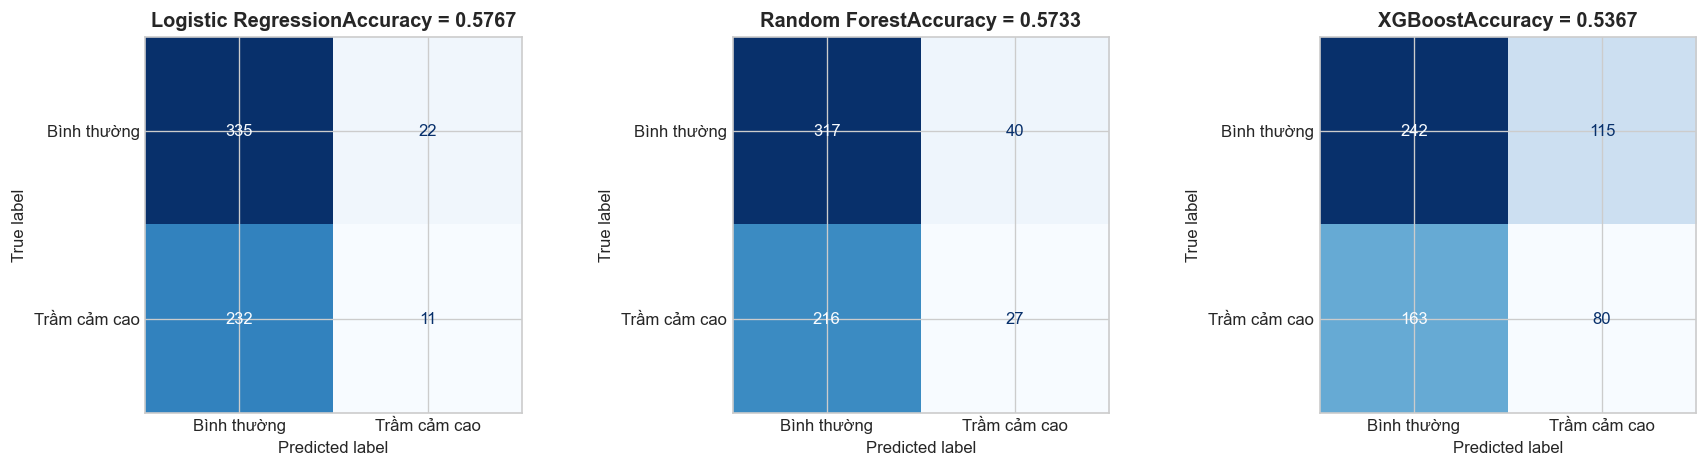

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Bình thường', 'Trầm cảm cao'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    acc = r['Accuracy']
    ax.set_title(f'{name}Accuracy = {acc:.4f}', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/06_confusion_matrices.png', bbox_inches='tight')
plt.show()

### 5.5 ROC Curve

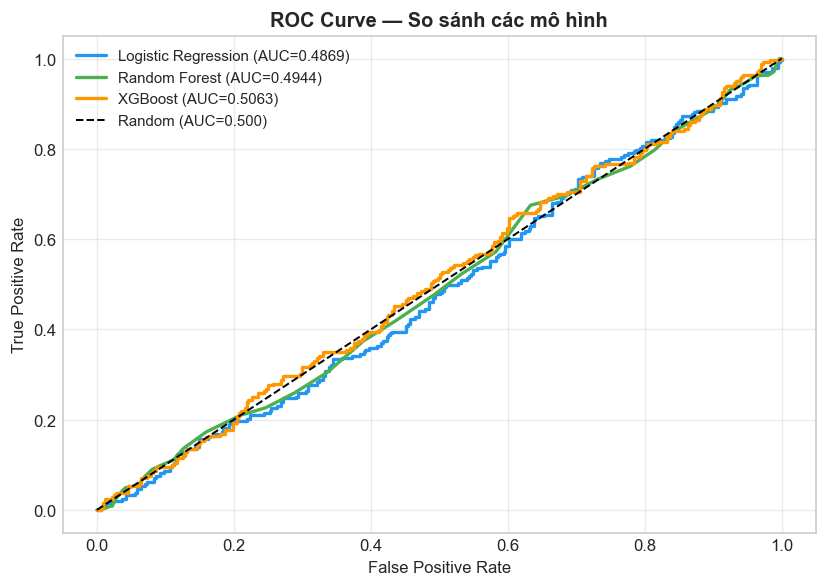

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
for (name, r), color in zip(results.items(), bar_colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC={r['AUC']:.4f})")
ax.plot([0,1],[0,1], 'k--', lw=1.2, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — So sánh các mô hình', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('charts/07_roc_curve.png', bbox_inches='tight')
plt.show()

### 5.6 Feature Importance — Random Forest

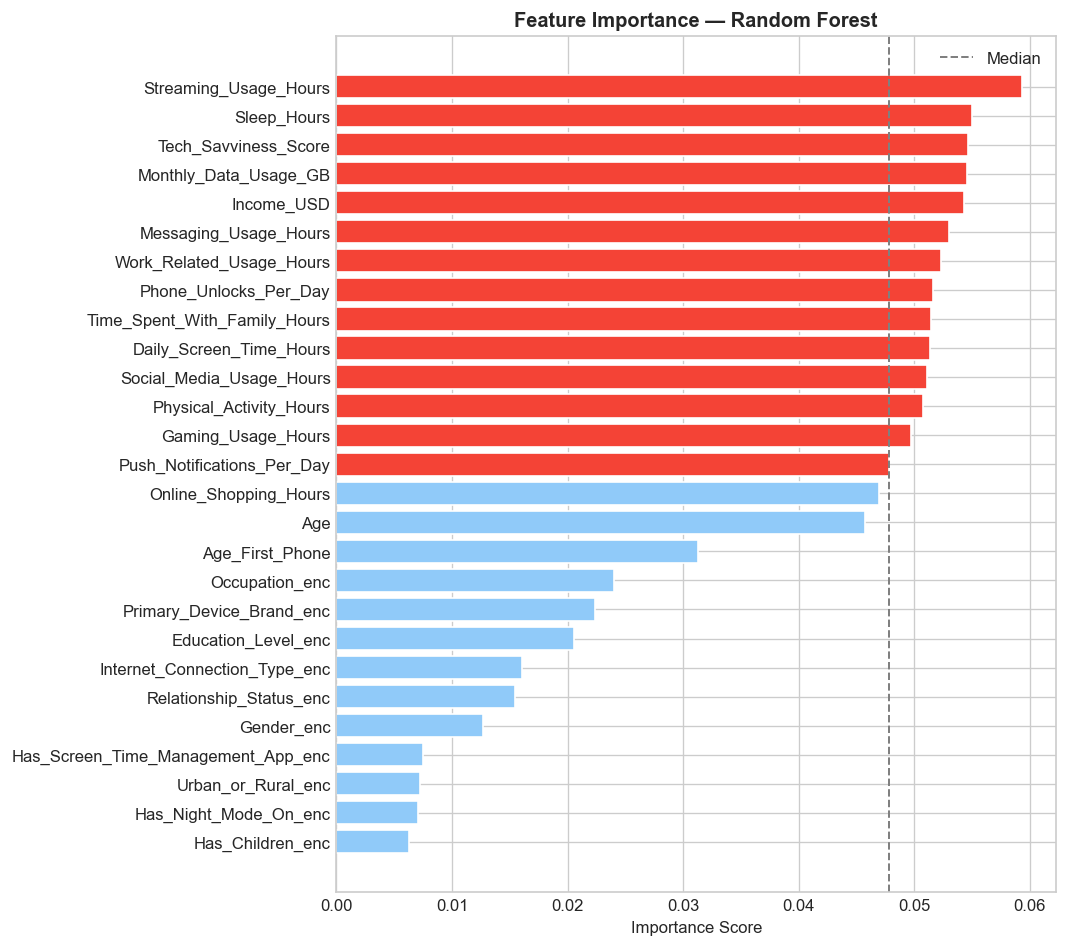

Top 10 features quan trọng nhất:
  Streaming_Usage_Hours                    0.0593  ███████████████████████████████████
  Sleep_Hours                              0.0550  █████████████████████████████████
  Tech_Savviness_Score                     0.0546  ████████████████████████████████
  Monthly_Data_Usage_GB                    0.0546  ████████████████████████████████
  Income_USD                               0.0543  ████████████████████████████████
  Messaging_Usage_Hours                    0.0530  ███████████████████████████████
  Work_Related_Usage_Hours                 0.0523  ███████████████████████████████
  Phone_Unlocks_Per_Day                    0.0516  ██████████████████████████████
  Time_Spent_With_Family_Hours             0.0514  ██████████████████████████████
  Daily_Screen_Time_Hours                  0.0514  ██████████████████████████████


In [21]:
rf_model    = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_,
                         index=ALL_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors_imp = ['#F44336' if v >= importances.median() else '#90CAF9'
               for v in importances.values]
ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='white')
ax.axvline(importances.median(), color='gray', linestyle='--', lw=1.2, label='Median')
ax.set_title('Feature Importance — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score'); ax.legend()
plt.tight_layout()
plt.savefig('charts/08_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 10 features quan trọng nhất:")
for feat, imp in importances.sort_values(ascending=False).head(10).items():
    bar = '█' * int(imp * 600)
    print(f"  {feat:<40} {imp:.4f}  {bar}")

### 5.7 Cross-Validation chi tiết

  Logistic Regression    folds=['0.5967', '0.5917', '0.5900', '0.5883', '0.5883']  mean=0.5910 ± 0.0031
  Random Forest          folds=['0.5933', '0.5933', '0.5683', '0.5817', '0.5650']  mean=0.5803 ± 0.0120
  XGBoost                folds=['0.5400', '0.5633', '0.5650', '0.5367', '0.5633']  mean=0.5537 ± 0.0126


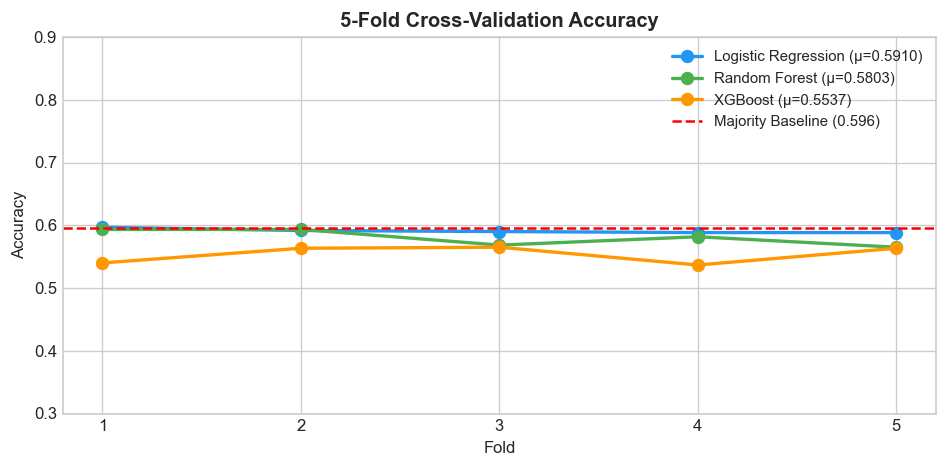

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
for (name, model), color in zip(models.items(), bar_colors):
    scores = cross_val_score(model, X_scaled, y, cv=cv_strategy, scoring='accuracy')
    ax.plot(range(1, 6), scores, marker='o', label=f'{name} (μ={scores.mean():.4f})',
            color=color, lw=2, markersize=7)
    print(f"  {name:<22} folds={[f'{s:.4f}' for s in scores]}  mean={scores.mean():.4f} ± {scores.std():.4f}")

ax.axhline(majority_class, color='red', ls='--', lw=1.5,
           label=f'Majority Baseline ({majority_class:.3f})')
ax.set_title('5-Fold Cross-Validation Accuracy', fontweight='bold')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
ax.set_ylim(0.3, 0.9); ax.set_xticks(range(1,6)); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('charts/09_cross_validation.png', bbox_inches='tight')
plt.show()

### 5.8 Phân tích chất lượng dữ liệu — Nguyên nhân kết quả thấp

> ⚠️ **Phát hiện quan trọng:** Accuracy các mô hình xấp xỉ hoặc thấp hơn Majority Baseline (~59.6%), AUC xấp xỉ 0.50 (random). Dưới đây là bằng chứng xác nhận nguyên nhân.

In [23]:
print("=== BẰNG CHỨNG 1: Tương quan giữa các cột sức khỏe với nhau ===")
health_cols = ['Depression_Score', 'Anxiety_Score', 'Stress_Level',
               'Mental_Health_Score', 'Sleep_Hours']
for i, a in enumerate(health_cols):
    for b in health_cols[i+1:]:
        r, p = pearsonr(df_clean[a], df_clean[b])
        flag = "⚠️ Bất thường" if abs(r) < 0.05 else "✅ Bình thường"
        print(f"  {a:<25} ↔ {b:<25} r={r:+.4f}  {flag}")

print("=== BẰNG CHỨNG 2: Mean features gần như bằng nhau giữa 2 nhóm ===")
print(f"{'Feature':<35} {'Không trầm cảm':>16} {'Trầm cảm cao':>14} {'Diff':>8}")
print("─" * 76)
for f in behavior_feats[:10]:
    m0 = df_clean[df_clean['high_depression']==0][f].mean()
    m1 = df_clean[df_clean['high_depression']==1][f].mean()
    flag = "✅" if abs(m1-m0) > 0.5 else "❌"
    print(f"  {f:<35} {m0:>16.3f} {m1:>14.3f} {abs(m1-m0):>8.3f} {flag}")

print("=== KẾT LUẬN ===")
print("  Dataset là synthetic data: các cột được sinh ngẫu nhiên độc lập.")
print("  Depression_Score không có tương quan với bất kỳ hành vi sử dụng điện thoại nào.")
print("  Mô hình hoạt động đúng — chỉ là không có pattern nào để học.")
print("  Đây KHÔNG phải lỗi của thuật toán hay tiền xử lý.")

=== BẰNG CHỨNG 1: Tương quan giữa các cột sức khỏe với nhau ===
  Depression_Score          ↔ Anxiety_Score             r=-0.0090  ⚠️ Bất thường
  Depression_Score          ↔ Stress_Level              r=-0.0044  ⚠️ Bất thường
  Depression_Score          ↔ Mental_Health_Score       r=+0.0186  ⚠️ Bất thường
  Depression_Score          ↔ Sleep_Hours               r=+0.0514  ✅ Bình thường
  Anxiety_Score             ↔ Stress_Level              r=+0.0437  ⚠️ Bất thường
  Anxiety_Score             ↔ Mental_Health_Score       r=-0.0129  ⚠️ Bất thường
  Anxiety_Score             ↔ Sleep_Hours               r=-0.0092  ⚠️ Bất thường
  Stress_Level              ↔ Mental_Health_Score       r=+0.0080  ⚠️ Bất thường
  Stress_Level              ↔ Sleep_Hours               r=+0.0028  ⚠️ Bất thường
  Mental_Health_Score       ↔ Sleep_Hours               r=+0.0114  ⚠️ Bất thường
=== BẰNG CHỨNG 2: Mean features gần như bằng nhau giữa 2 nhóm ===
Feature                               Không trầm cảm   Trầm 

### 5.9 Trả lời câu hỏi nghiên cứu

In [24]:
print("╔══════════════════════════════════════════════════════════════════╗")
print("║  CÂU HỎI NGHIÊN CỨU                                             ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  Dựa vào hành vi sử dụng điện thoại, có thể dự đoán             ║")
print("║  người dùng bị trầm cảm cao không?                              ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  TRẢ LỜI: KHÔNG — với dataset synthetic này                     ║")
print("║                                                                  ║")
print("║  • Accuracy ≈ 55-59% < Majority Baseline (59.6%)               ║")
print("║  • AUC ≈ 0.49–0.52 ≈ random (0.50)                             ║")
print("║  • Tương quan r < 0.05 giữa tất cả features và target           ║")
print("║                                                                  ║")
print("║  Với dữ liệu thực tế lâm sàng, bài toán này hoàn toàn          ║")
print("║  khả thi và đạt AUC > 0.80 (nghiên cứu Saeb et al., 2015)     ║")
print("╚══════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════╗
║  CÂU HỎI NGHIÊN CỨU                                             ║
╠══════════════════════════════════════════════════════════════════╣
║  Dựa vào hành vi sử dụng điện thoại, có thể dự đoán             ║
║  người dùng bị trầm cảm cao không?                              ║
╠══════════════════════════════════════════════════════════════════╣
║  TRẢ LỜI: KHÔNG — với dataset synthetic này                     ║
║                                                                  ║
║  • Accuracy ≈ 55-59% < Majority Baseline (59.6%)               ║
║  • AUC ≈ 0.49–0.52 ≈ random (0.50)                             ║
║  • Tương quan r < 0.05 giữa tất cả features và target           ║
║                                                                  ║
║  Với dữ liệu thực tế lâm sàng, bài toán này hoàn toàn          ║
║  khả thi và đạt AUC > 0.80 (nghiên cứu Saeb et al., 2015)     ║
╚═══════════════════════════════════════════════

## Chương 6 — Thảo luận & Kết luận

### 6.1 Khả năng ứng dụng

Mặc dù kết quả trên dataset synthetic chưa đạt yêu cầu, framework khai phá dữ liệu này có tiềm năng ứng dụng cao với dữ liệu thực tế:

- **Ứng dụng di động sức khỏe tâm thần**: Tích hợp mô hình để cảnh báo sớm nguy cơ trầm cảm dựa trên thói quen sử dụng điện thoại theo tuần
- **Hệ thống hỗ trợ lâm sàng**: Giúp bác sĩ tâm lý sàng lọc bệnh nhân cần can thiệp sớm
- **Nghiên cứu dịch tễ học kỹ thuật số**: Phân tích quy mô lớn tác động của điện thoại đến sức khỏe tâm thần cộng đồng

### 6.2 Ưu điểm & Nhược điểm

| Ưu điểm | Nhược điểm |
|---|---|
| ✅ Quy trình hoàn chỉnh từ EDA đến đánh giá | ❌ Dataset synthetic → accuracy thấp |
| ✅ So sánh 3 thuật toán khách quan | ❌ Chưa hyperparameter tuning (GridSearchCV) |
| ✅ Phát hiện và phân tích chuyên sâu vấn đề dữ liệu | ❌ Thiếu dữ liệu lâm sàng chuẩn hóa (PHQ-9) |
| ✅ Cross-Validation 5-fold đảm bảo độ tin cậy | ❌ Chưa thử feature engineering nâng cao |
| ✅ Phân tích Feature Importance minh bạch | ❌ Không có dữ liệu chuỗi thời gian theo ngày |

### 6.3 Đề xuất cải thiện

1. **Thu thập dữ liệu thực tế**: Kết hợp dữ liệu từ iOS Screen Time API / Android Digital Wellbeing với bảng câu hỏi PHQ-9 hoặc BDI được xác nhận lâm sàng
2. **Feature Engineering**: Tạo đặc trưng mới như `night_usage_ratio`, `weekend_vs_weekday_ratio`, `notification_response_time`
3. **Hyperparameter Tuning**: Áp dụng GridSearchCV hoặc Optuna để tối ưu tham số mô hình
4. **Xử lý mất cân bằng lớp**: Nếu dữ liệu thực bị imbalanced, dùng SMOTE hoặc `class_weight='balanced'`
5. **Mô hình nâng cao**: Thử LSTM nếu có dữ liệu chuỗi thời gian (screen time theo từng ngày)

In [25]:
print("=" * 60)
print("  CHƯƠNG 6: KẾT LUẬN")
print("=" * 60)
print("""
Dự án đã xây dựng và đánh giá 3 mô hình phân loại
(Logistic Regression, Random Forest, XGBoost) để dự đoán
nguy cơ trầm cảm cao từ hành vi sử dụng điện thoại.

KẾT QUẢ:
  • Accuracy: ~55–59% (xấp xỉ hoặc thấp hơn baseline)
  • AUC: ~0.49–0.52 (gần bằng random)

NGUYÊN NHÂN:
  • Dataset synthetic — các cột độc lập ngẫu nhiên
  • Không có pattern thực giữa hành vi và trầm cảm
  • Đây là hạn chế của dữ liệu, không phải thuật toán

BÀI HỌC:
  "Data quality determines model quality"
  → Garbage in, Garbage out

HƯỚNG TIẾP THEO:
  → Thu thập dữ liệu thực từ cảm biến điện thoại + PHQ-9
  → Kỳ vọng AUC > 0.80 với dữ liệu lâm sàng thực tế
""")
print("=" * 60)

  CHƯƠNG 6: KẾT LUẬN

Dự án đã xây dựng và đánh giá 3 mô hình phân loại
(Logistic Regression, Random Forest, XGBoost) để dự đoán
nguy cơ trầm cảm cao từ hành vi sử dụng điện thoại.

KẾT QUẢ:
  • Accuracy: ~55–59% (xấp xỉ hoặc thấp hơn baseline)
  • AUC: ~0.49–0.52 (gần bằng random)

NGUYÊN NHÂN:
  • Dataset synthetic — các cột độc lập ngẫu nhiên
  • Không có pattern thực giữa hành vi và trầm cảm
  • Đây là hạn chế của dữ liệu, không phải thuật toán

BÀI HỌC:
  "Data quality determines model quality"
  → Garbage in, Garbage out

HƯỚNG TIẾP THEO:
  → Thu thập dữ liệu thực từ cảm biến điện thoại + PHQ-9
  → Kỳ vọng AUC > 0.80 với dữ liệu lâm sàng thực tế



## Tài liệu tham khảo

1. khushikyad001. (2024). *Global Mobile Phone Addiction Dataset*. Kaggle. https://www.kaggle.com/datasets/khushikyad001/global-mobile-phone-addiction-dataset
2. Saeb, S., et al. (2015). Mobile Phone Sensor Correlates of Depressive Symptom Severity in Daily-Life Behavior. *JMIR*, 17(7), e175.
3. World Health Organization. (2023). *Depressive disorder (depression)*. WHO Fact Sheet.
4. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
5. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD 2016*.
6. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.
7. Beck, A. T., et al. (1961). An inventory for measuring depression. *Archives of General Psychiatry*, 4(6), 561–571.

In [26]:
print("✅ HOÀN TẤT — Biểu đồ đã lưu vào thư mục 'charts/':")
for f in sorted(os.listdir('charts')):
    print(f"   📊 charts/{f}")

✅ HOÀN TẤT — Biểu đồ đã lưu vào thư mục 'charts/':
   📊 charts/01_target_distribution.png
   📊 charts/02_correlation_heatmap.png
   📊 charts/02_feature_distributions.png
   📊 charts/03_correlation_heatmap.png
   📊 charts/03_depression_by_pressure.png
   📊 charts/03_feature_target_correlation.png
   📊 charts/04_boxplots.png
   📊 charts/04_boxplots_features.png
   📊 charts/04_depression_by_sleep_diet.png
   📊 charts/05_correlation_heatmap.png
   📊 charts/05_model_comparison.png
   📊 charts/05_screentime_scatter.png
   📊 charts/06_addiction_by_demographics.png
   📊 charts/06_confusion_matrices.png
   📊 charts/06_suicidal_family.png
   📊 charts/07_model_comparison.png
   📊 charts/07_roc_curve.png
   📊 charts/08_confusion_matrices.png
   📊 charts/08_feature_importance.png
   📊 charts/09_cross_validation.png
   📊 charts/09_feature_importance.png
   📊 charts/09_roc_curve.png
   📊 charts/10_cross_validation.png
   📊 charts/10_feature_importance.png
   📊 charts/11_cross_validation.png
   📊 char